# Synthetic Periodic Time Series

This notebook focuses on oscillatory signals—single/multiple sine waves, cosine, triangle, sawtooth, square, sinc, exponential-sine hybrids, and related periodic motifs—and saves/visualizes each variant for downstream forecasting or anomaly detection experiments.


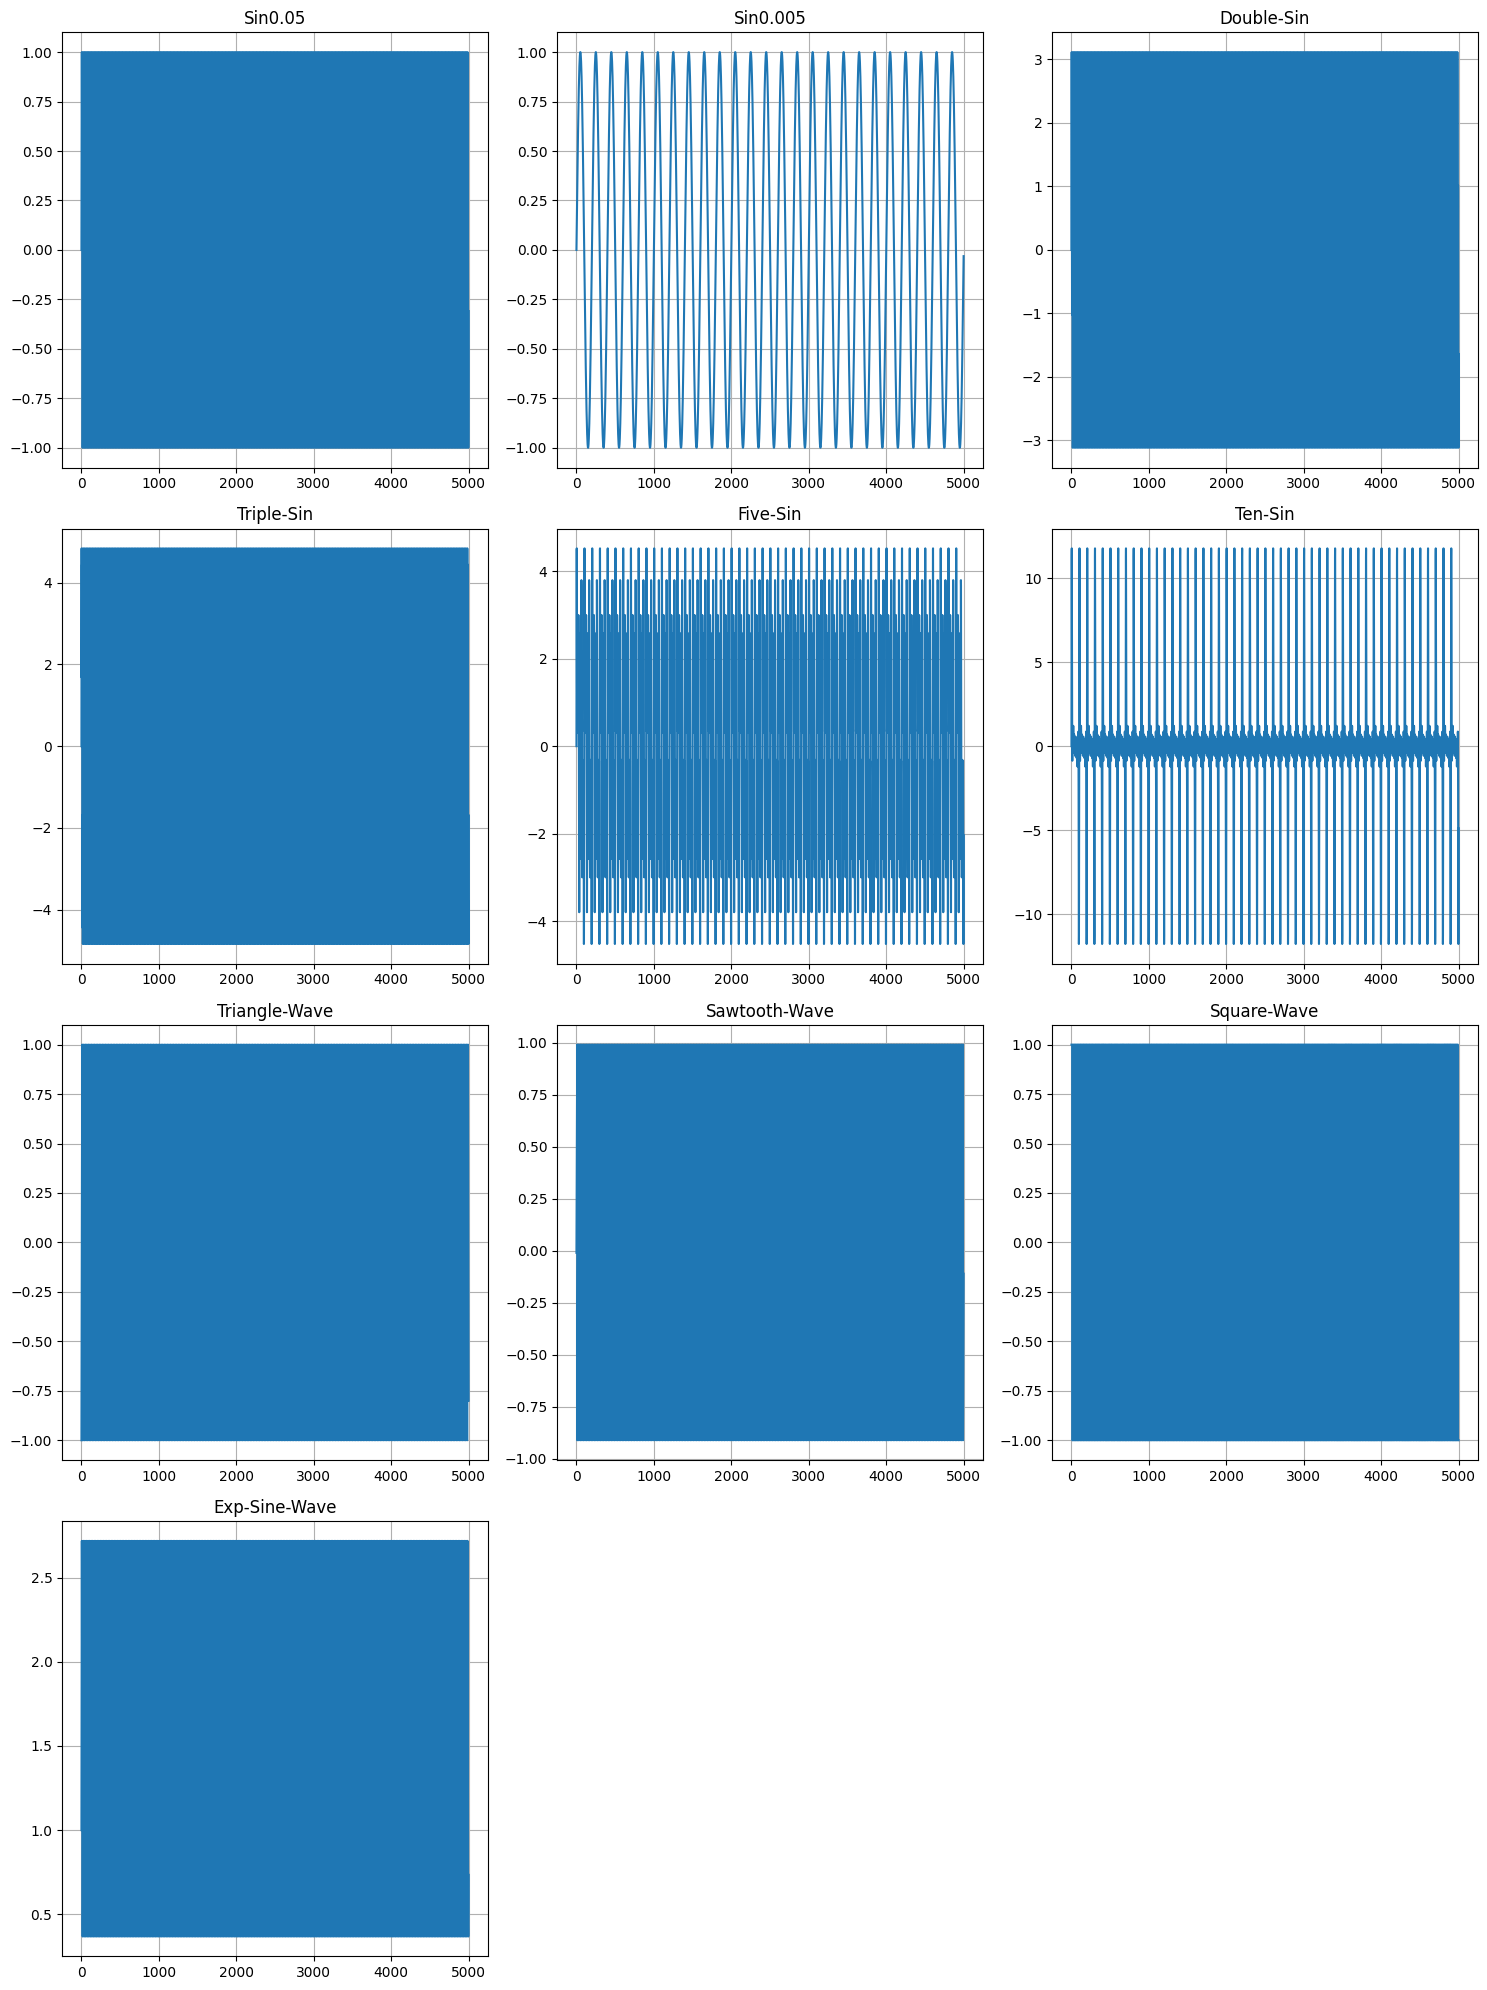

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from statsmodels.tsa.arima_process import ArmaProcess
import pandas as pd

# Shared helper functions for signal generation/noise utilities
try:
    from dataset.signal_generators import *
except ModuleNotFoundError:
    from signal_generators import *

# Main functions
def generate_and_save_datasets(seed, dataset_folder, dataset_id):
    """Generate and save a dataset with multiple signal types."""
    n = 5000  # Signal length
    np.random.seed(seed)  # Set random seed

    signal_generators = {
        "Sin0.05": lambda: generate_sine_wave(n, amplitude=1, frequency=0.05),
        "Sin0.005": lambda: generate_sine_wave(n, amplitude=1, frequency=0.005),
        "Double-Sin": lambda: generate_composite_sine(n, [(2, 0.1, 0), (1.5, 0.05, 0)]),
        "Triple-Sin": lambda: generate_composite_sine(n, [(1, 0.2, 0), (2, 0.15, 0), (4, 0.05, 0)]),
        "Five-Sin": lambda: generate_composite_sine(n, [
            (1, 0.01, 0), (1.2, 0.02, 0), (2, 0.05, 0),(1.4, 0.08, 0), (0.9, 0.1, 0)
        ]),
        "Ten-Sin": lambda: generate_composite_sine(n, [
            (1, 0.01, 0), (1.2, 0.02, 0), (1.5, 0.03, 0), (1.8, 0.04, 0), (2, 0.05, 0),
            (2.2, 0.06, 0), (1.7, 0.07, 0), (1.4, 0.08, 0), (1.1, 0.09, 0), (0.9, 0.1, 0)
        ]),
        "Triangle-Wave": lambda: generate_triangle_wave(n, amplitude=1, frequency=0.05),
        "Sawtooth-Wave": lambda: generate_sawtooth_wave(n, amplitude=1, frequency=0.05),
        "Square-Wave": lambda: generate_square_wave(n, amplitude=1, frequency=0.05),
        "Exp-Sine-Wave": lambda: generate_exp_sine_wave(n, amplitude=1, frequency=0.05),
    }

    # 1. Generate and save raw dataset
    signal_data_dict = {}
    for signal_name, generator in signal_generators.items():
        signal_data = generator()
        signal_data_dict[signal_name] = signal_data
        save_signal(signal_data, dataset_folder, signal_name, dataset_id=dataset_id, category="raw", length=n)

    # Visualize original signals
    plot_signals(signal_data_dict)

def generate_multiple_datasets(num_datasets=5):
    """Generate multiple datasets with different random seeds."""
    output_folder = "Dataset_generated_period"  
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    for i in range(num_datasets):
        seed = i  
        generate_and_save_datasets(seed, output_folder, i+1)

if __name__ == "__main__":
    generate_multiple_datasets(num_datasets=1)